*updated 25 Aug 2025, Jonathan Lee (whatever with copyright, do what you want with this)

### As part of material for OCES 4303 "AI and Machine Learning in Marine Science" delivered at HKUST

For the latest version of the material, go to the public facing [GitHub](https://github.com/julianmak/OCES4303_ML_ocean) page.

---
# $9\frac{3}{4}$. More Pytorch and Transfer Learning

Below mainly comprise of two parts. First part will be more on Pytorch and second part is about transfer learning.

> !!!NOTE!!! It is advisable to use a GPU (on Colab for example) for the transfer learning part.

Just a warning. If you are new to Pytorch, the code below could be overwhelming. There are certainly a lot of functions, objects and fancy commands, linking each other and making it quite convoluted. While the source code is available, I would suggest reading the documentations and docstring only, and trust the code will do the *magic* for you, which makes you easier to understand and read through in a reasonable amount of time.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/8e/Platform_9_3-4_%28King%27s_Cross_station%2C_London%2C_2014%29.jpg" width="300" alt='magic at 9.75'>

In [1]:
import numpy as np
import pandas as pd
from timeit import default_timer as timer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Pytorch
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transform
# this seems newer (and faster?)
from torchvision.transforms import v2

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

[INFO] Couldn't find torchinfo... installing it.


Use GPU to speed up the training if available. Google Colab sometimes has free GPU available, albeit not guaranteed.

NOTE: Have not tried the TPU.

In [2]:
# check whether GPU is available
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cuda'

## `Dataset` and `Dataloader`

Pytorch encourges users to write everything according to a "standard". In particular, there is a special way of organising data, by putting data into `Dataset` and `Dataloader`. Putting them into standard formats allows (probably) more efficient computations and easier management of data, especially when it comes to **batching** (and mini-batching). But the disadvantage is obvious. It requires good understanding of Python, good understanding of object-oriented programming and is tedious to write all the objects. *(Not sure what you think but it's a headache for me😞)*

While in our previous CNNs notebook we manage to the oragnise data, do training and testing without `Dataset` and `Dataloader`. Let's try to do things according to the "standard". Below is code to wrap our previous data of cats and dogs into `Dataset` and `Dataloader`, somewhat following [here](https://www.kaggle.com/code/jiazhuang/cnn-with-pytorch-for-beginners/notebook), and [here](https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html).

In [3]:
# load the Cat and Dog dataset
# don't read the headers

option = "remote"

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "cat.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/cat.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_cats = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_cats = np.transpose(df_cats.values.reshape(-1, 64, 64), axes=(0,2,1))

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "dog.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/dog.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_dogs = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_dogs = np.transpose(df_dogs.values.reshape(-1, 64, 64), axes=(0,2,1))

total_sample = 80*2
X_total = np.concatenate((X_cats, X_dogs), axis=0)
Y_total = np.concatenate((np.ones(int(total_sample/2)), np.zeros(int(total_sample/2))))

# checking
print(f"X_dogs shape: {X_dogs.shape}")
print(f"X_cats shape: {X_cats.shape}")
print(f"X_total shape: {X_total.shape}")
print(f'Y_total shape: {Y_total.shape}')

loading data remotely
loading data remotely
X_dogs shape: (80, 64, 64)
X_cats shape: (80, 64, 64)
X_total shape: (160, 64, 64)
Y_total shape: (160,)


There are many ways to write the constructor. I choose to read all the data remotely and then pass to constructor.

In [4]:
class CatDogDataset(Dataset):
  def __init__(self, data, labels, transform=None, target_transform=None):
    """
    Argruments
    ----------
    data (numpy.ndarray): data in shape: (no_of_sample, data_dim)
    labels (numpy.ndarray): data labels in shape: (no_of_sample,)
    transform (callable, optional): Optional transform to be applied on a sample.
    """
    self.data = data
    self.labels = labels
    assert labels.shape[0] == data.shape[0], \
      "Inconsistent no_of_sample between data and labels"
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    # return no of samples
    return len(self.labels)

  def __getitem__(self, index):
    image = self.data[index, :]
    label = self.labels[index]
    # add a channel dim
    if isinstance(index, list):
      # (N, H, W, C)
      image = image.reshape(image.shape[0], image.shape[1], image.shape[2], 1)
    else:
      # (H, W, C)
      image = image.reshape(image.shape[-2], image.shape[-1], 1)

    if self.transform:
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(label)

    return image, label

Above might require some explanations.

- `__init__`: the constructor. It is run once and is for instantiating the Dataset object. Here we initialise by putting the data, the labels, the transform for dataset and transform for labels (will explain `transform` later). Of course there are many other ways to write this, e.g. construct using paths.

- `__len__`: when called using `len()`, will return what is defined. Here it is the number of samples.

- `__getitem__`: returns a sample from the dataset at the given `index`.

In [5]:
# no transform just yet, explain later
catdog_dataset = CatDogDataset(X_total, Y_total)

# try len
print(f'Calling __len__: {len(catdog_dataset)}')

# getitem
print("Getting one item ...")
idx = 88
one_image, one_label = catdog_dataset[idx]
print(f"shape of one_image: {one_image.shape}")
print(f"shape of one_label: {one_label.shape}")

# getitem
print("Getting multiple items ...")
idx = [1, 67, 156]
some_images, some_labels = catdog_dataset[idx]
print(f"shape of some_images: {some_images.shape}")
print(f"shape of some_labels: {some_labels.shape}")

Calling __len__: 160
Getting one item ...
shape of one_image: (64, 64, 1)
shape of one_label: ()
Getting multiple items ...
shape of some_images: (3, 64, 64, 1)
shape of some_labels: (3,)


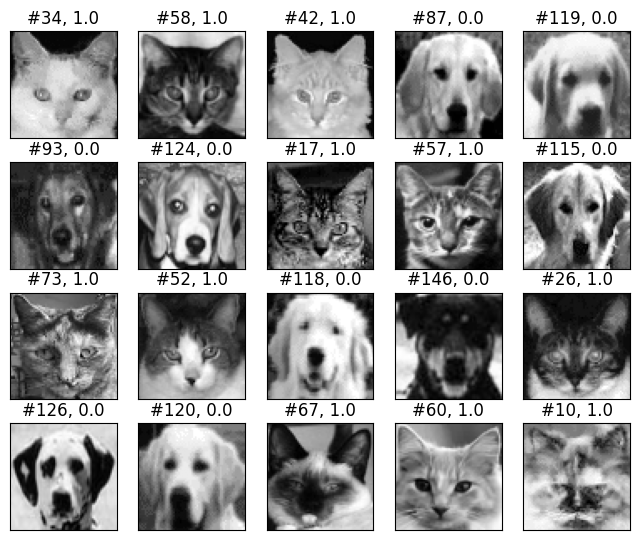

In [6]:
ind = np.arange(160)
np.random.shuffle(ind)

fig = plt.figure(figsize=(8, 6.5))
for i in range(20):
    ax = plt.subplot(4, 5, i+1)
    this_image, this_label = catdog_dataset[ind[i]]
    ax.imshow(this_image.squeeze(), cmap="gray")
    ax.set_title(f"#{ind[i]}, {this_label}")
    ax.set_xticks([]); ax.set_yticks([]);

Notice I have not done anything with standardisation/Normalisation or `transform`. We will do it now.

X_total_uint8: 0 ... 255
Before transform: Shape of one image: (160, 64, 64)
Before transform: Shape of one image: torch.Size([3, 224, 224])
this_image: 0.04313725605607033 ... 0.9098039865493774
After transform: Shape of one image: torch.Size([3, 224, 224])


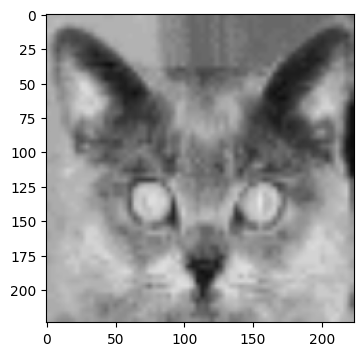

In [7]:
# The image needs to be in dtype=uint8 to make work
X_total_uint8 = X_total.astype(np.uint8)
# print the range
print(f"X_total_uint8: {X_total_uint8.min()} ... {X_total_uint8.max()}")
# print the shape
print(f"Before transform: Shape of one image: {X_total_uint8.shape}")

the_transform = transform.Compose([
    v2.ToPILImage(),                        # Seems the below needs a PIL image
    v2.Resize((224, 224)),                  # resize the image
    v2.Grayscale(num_output_channels=3),    # Replicate grayscale -> RGB
    # NOTE: ToTensor seems deprecated, use ToImage & ToDtype instead; does the same thing
    # v2.ToTensor(),                        # normalise to [0, 1]; also (H, W, C) -> (C, H ,W)
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # use later, for visualisation dont do normalize just yet
    # transform.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# pass the transform (callable) to the object, perform on-spot
catdog_dataset = CatDogDataset(X_total_uint8, Y_total, transform=the_transform)

idx = 40
this_image, this_label = catdog_dataset[idx]
# (H, W, C)
print(f"Before transform: Shape of one image: {this_image.shape}")

fig, ax = plt.subplots(figsize=(4, 4))
# show only one channel
ax.imshow(np.transpose(this_image.squeeze(), (1,2,0)), cmap="gray")
# print the range
print(f"this_image: {this_image.min()} ... {this_image.max()}")
# print the shape
print(f"After transform: Shape of one image: {this_image.shape}")

In the above, the transformation consists of several things. though some of the them are formalities (code reason):

- `Compose` is just a wrapper containing all the transformations.
- `ToPILImage` convert a tensor or an ndarray to PIL Image. Also changes the shape from `(C, H, W)` to `(H, W, C)`.
- `Resize` will resize the image to give shape by interpolation (default is bilinear). This is for ***transfer learning*** later.
- `Grayscale(num_output_channels=3)` is originally for converting images to Grayscale. Since our input images are grayscale already, this operation will only make it into 3 channels. This is for ***transfer learning*** later.
- `ToImage` convert a tensor or ndarray or PIL image to `Image`, which is a sub-class of `torch.Tensor`. Expect image with shape `(..., C, H, W)`.
- `ToDtype` changes the data type. `scale=True` kwargs will scale the image to have the range [0,1].
- `Normalize` will scale the image to the input mean and standard deviation.

> NOTE: `torchvision.transforms.v2` is the new transformation class, which is faster and contains more transformation. The legacy one is `torchvision.transforms`.
>
> `ToImage` and `ToDtype` together replaced the deprecated `ToTensor`.

Of course we can add more transformations; here is a more complicated example. There are many more transfromations that you are welcome to try, but there is no guarantee in boosting performance. For further details, I would suggest you start [here](https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html).

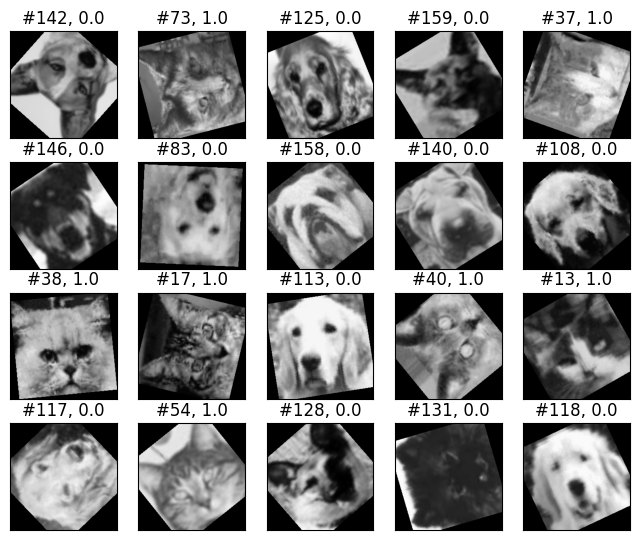

In [8]:
# can do more transform, but did not pass to object
# just do it outside
more_transform = transform.Compose([
    # Pad the image will some empty (or dark) padding
    v2.Pad(10),
    # well randomly flip the images horizontally
    v2.RandomHorizontalFlip(p=0.5),
    # can also rotate the images (can specify higher degree of rotation)
    v2.RandomRotation(degrees=(0, 180))
    ])

ind = np.arange(160)
np.random.shuffle(ind)

fig = plt.figure(figsize=(8, 6.5))
for i in range(20):
    ax = plt.subplot(4, 5, i+1)
    this_image, this_label = catdog_dataset[ind[i]]

    # more transform here
    this_image_trans = more_transform(this_image)

    ax.imshow(np.transpose(this_image_trans.squeeze(), (1,2,0)), cmap="gray")
    ax.set_title(f"#{ind[i]}, {this_label}")
    ax.set_xticks([]); ax.set_yticks([]);

With `Dataset` defined, we can simply put it into the `dataloader` object. Notice the dataset is **not shuffled**. We shall handle the shuffling via `DataLoader` (`shuffle=True`).

In [9]:
batch_size = 16

catdog_dataloader = DataLoader(catdog_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

image_batch shape: torch.Size([16, 3, 224, 224])
label_batch shape: torch.Size([16])


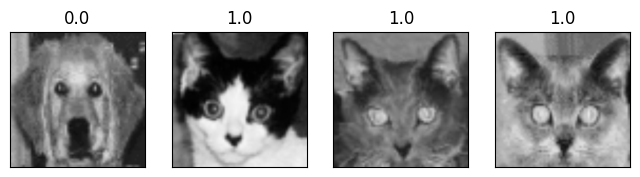

In [10]:
image_batch, label_batch = next(iter(catdog_dataloader))
print(f"image_batch shape: {image_batch.shape}")
print(f"label_batch shape: {label_batch.shape}")

# show 4 of them
fig = plt.figure(figsize=(8, 4))
for i in range(4):

    ax = plt.subplot(1, 4, i+1)

    ax.imshow(np.transpose(image_batch[i].squeeze(), (1,2,0)), cmap="gray")
    ax.set_title(f"{label_batch[i]}")
    ax.set_xticks([]); ax.set_yticks([]);

`iter()` calls on an iterable object and convert to an iterator object. `next` retrieves the subsequent item from the sequence. Hence, running `next(iter(catdog_dataloader))` continuously will go through the batch.



---
## Transfer Learning

The Machine Learning communities have made significant progress over the decade and put forward various Neural Network architectures that have good performance (through trial and error mostly). In order to obtain good performance, the number of parameters incerases drastically (million to billion), and people have already trained these large models and make them publicly available. They train on a large and diversified dataset, of which we do not have access to. Also, their architectures are often too complicated to emulate.

However, we can somehow leverage their trained model for our task. The idea of ***transfer learning*** is that we build on top of their pre-trained model, and only re-train part of the model. e.g. we could fine tune the weights for only a few layers, or modify the some layers (usually the last layer). Using the learnt features, the model can efficiently adapt to the new task, and does not need to re-train from scratch. This is also ideal for our case as we have limited amount of data.

The analogy for transfer learning is that for a company or university etc.: for a new task/position, you would hire a highly-educated adult rather than a child who have received very few training/education. A highly-educated adult will definitely require fewer training time to be suited to the new task.

I am no expert in Pytorch and Machine Learning, so I mostly follow the tutorial
[here](https://www.learnpytorch.io/06_pytorch_transfer_learning/) and [here](https://www.geeksforgeeks.org/deep-learning/how-to-implement-transfer-learning-in-pytorch/) for the below transfer learning example.

Below performed transfer learning for our cat and dog dataset, using the `ResNet50` ([doc](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html), [paper](https://arxiv.org/abs/1512.03385)) as the foundation model. 50 means 50 layers. There are others, like `AlexNet`, `VGG`, `GoogLeNet`, `MobileNet` etc. These models are already quite *old* (~6-10 years ago).

There are a lot of analysis / discussion as to why ResNet could perform well in image classification / recognition. It is also some of earlier models using *skip connection*, which later become popular (Chat Generative Pre-Trained Transformer also has). I will not repeat them here as this notebook is not about ResNet.

In [11]:
# let's redefine the dataset and dataloader for clarity
# also train-test-valid split
seed = 42
train_ratio = 0.8
valid_ratio = 0.1
test_ratio = 1 - train_ratio - valid_ratio
test_valid_ratio = test_ratio + valid_ratio
total_sample = 80*2

# The image needs to be in dtype=uint8 to make work
X_total_uint8 = X_total.astype(np.uint8)

the_transform = transform.Compose([
    v2.ToPILImage(),
    v2.Resize((224, 224)),
    v2.Grayscale(num_output_channels=3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    transform.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

catdog_dataset = CatDogDataset(X_total_uint8,
                               torch.LongTensor(Y_total),
                               transform=the_transform,)

train_dataset, test_dataset, valid_dataset = random_split(catdog_dataset,
 [train_ratio, test_ratio, valid_ratio])
print(f"(train, test, valid) : ({len(train_dataset)}, {len(test_dataset)}, {len(valid_dataset)})")

(train, test, valid) : (129, 15, 16)


In [12]:
# define the dataloader
batch_size = 8
train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
valid_dl = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

In [13]:
# Get a set of pretrained model weights
# .DEFAULT = best available weights from pretraining on ImageNet

weights = torchvision.models.ResNet50_Weights.DEFAULT
model = torchvision.models.resnet50(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 58.3MB/s]


In [14]:
# Print a summary using torchinfo
summary(model,
        input_size=(1, 3, 244, 244),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [1, 3, 244, 244]     [1, 1000]            --                   True
├─Conv2d (conv1)                         [1, 3, 244, 244]     [1, 64, 122, 122]    9,408                True
├─BatchNorm2d (bn1)                      [1, 64, 122, 122]    [1, 64, 122, 122]    128                  True
├─ReLU (relu)                            [1, 64, 122, 122]    [1, 64, 122, 122]    --                   --
├─MaxPool2d (maxpool)                    [1, 64, 122, 122]    [1, 64, 61, 61]      --                   --
├─Sequential (layer1)                    [1, 64, 61, 61]      [1, 256, 61, 61]     --                   True
│    └─Bottleneck (0)                    [1, 64, 61, 61]      [1, 256, 61, 61]     --                   True
│    │    └─Conv2d (conv1)               [1, 64, 61, 61]      [1, 64, 61, 61]      4,096                True
│    │    └─BatchN

As you can see, many blocks are present, and each block has several layers. I am going to only change the `Linear` layer.

In [15]:
# freezing the base model and changing the output layer
for param in model.parameters():
    param.requires_grad = False

In [16]:
# current classifier layer / last layer
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [17]:
# adjust the output layer
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# cats and dogs = (0, 1)
output_shape = 2

model.fc = torch.nn.Sequential(
    torch.nn.Linear(in_features=2048, out_features=1000, bias=True),
    torch.nn.Linear(in_features=1000, out_features=output_shape, bias=True)).to(device)

In [18]:
# print the model after updates
# Print a summary using torchinfo
summary(model,
        input_size=(1, 3, 244, 244),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [1, 3, 244, 244]     [1, 2]               --                   Partial
├─Conv2d (conv1)                         [1, 3, 244, 244]     [1, 64, 122, 122]    (9,408)              False
├─BatchNorm2d (bn1)                      [1, 64, 122, 122]    [1, 64, 122, 122]    (128)                False
├─ReLU (relu)                            [1, 64, 122, 122]    [1, 64, 122, 122]    --                   --
├─MaxPool2d (maxpool)                    [1, 64, 122, 122]    [1, 64, 61, 61]      --                   --
├─Sequential (layer1)                    [1, 64, 61, 61]      [1, 256, 61, 61]     --                   False
│    └─Bottleneck (0)                    [1, 64, 61, 61]      [1, 256, 61, 61]     --                   False
│    │    └─Conv2d (conv1)               [1, 64, 61, 61]      [1, 64, 61, 61]      (4,096)              False
│    │    



Last few lines of the summary:


```
========================================================================================================================
Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
========================================================================================================================
│    │    .....
│    └─Bottleneck (2)                    [1, 2048, 8, 8]      [1, 2048, 8, 8]      --                   False
│    │    └─Conv2d (conv1)               [1, 2048, 8, 8]      [1, 512, 8, 8]       (1,048,576)          False
│    │    └─BatchNorm2d (bn1)            [1, 512, 8, 8]       [1, 512, 8, 8]       (1,024)              False
│    │    └─ReLU (relu)                  [1, 512, 8, 8]       [1, 512, 8, 8]       --                   --
│    │    └─Conv2d (conv2)               [1, 512, 8, 8]       [1, 512, 8, 8]       (2,359,296)          False
│    │    └─BatchNorm2d (bn2)            [1, 512, 8, 8]       [1, 512, 8, 8]       (1,024)              False
│    │    └─ReLU (relu)                  [1, 512, 8, 8]       [1, 512, 8, 8]       --                   --
│    │    └─Conv2d (conv3)               [1, 512, 8, 8]       [1, 2048, 8, 8]      (1,048,576)          False
│    │    └─BatchNorm2d (bn3)            [1, 2048, 8, 8]      [1, 2048, 8, 8]      (4,096)              False
│    │    └─ReLU (relu)                  [1, 2048, 8, 8]      [1, 2048, 8, 8]      --                   --
├─AdaptiveAvgPool2d (avgpool)            [1, 2048, 8, 8]      [1, 2048, 1, 1]      --                   --
├─Sequential (fc)                        [1, 2048]            [1, 2]               --                   True
│    └─Linear (0)                        [1, 2048]            [1, 1000]            2,049,000            True
│    └─Linear (1)                        [1, 1000]            [1, 2]               2,002                True
```

The final two layers are the only trainable layers, other layers are **frozen** ❄. Also the last layer is changed to two `Linear` layers, instead of one.




Below is the training functions and loop. I follow [here](https://www.learnpytorch.io/05_pytorch_going_modular/#4-creating-train_step-and-test_step-functions-and-train-to-combine-them) for convenience, but these are quite standard training procedures.

NOTE: I did not save the best-performing weights at each epoch, hence the only available trained weights are at the *last epoch*.

In [19]:
from typing import Tuple, Dict, List
from tqdm.auto import tqdm
 # now we train our model, but first we define helper functions

def train_one_epoch(model: torch.nn.Module,
                    dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    device: torch.device) -> Tuple[float, float]:
    """
    Train a Pytorch model for one epoch.

    Returns
    -------
    A tuple of training loss and training accuracy metrics.
    (train_loss, train_accuracy)
    """
    # put the model in train model
    model.train()

    train_loss , train_acc = 0, 0
    # loop through dataloader batches
    for batch, (X, y) in enumerate(dataloader):
        # send data to device
        X, y = X.to(device), y.to(device)
        # forward
        y_pred = model(X)
        # add loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        # backprapa.
        loss.backward()

        # step / descent
        optimizer.step()
        # accuracy metric
        # NOTE: not sure why softmax here
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # adjust the metric to get the average loss
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def valid_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device: torch.device) -> Tuple[float, float]:
    """
    Test/valid a Pytorch model for a single epoch.
    Returns
    -------
    A tuple of validation loss and validation accuracy metrics.
    (valid_loss, valid_accuracy)
    """
    # put the model in eval mode
    model.eval()

    valid_loss, valid_acc = 0, 0
    # Turn on inference context manager
    # sth similar to no_grad
    with torch.inference_mode():
        # Loop over the dataloader
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
            # forward
            valid_pred = model(X)
            # add loss
            loss = loss_fn(valid_pred, y)
            valid_loss += loss.item()
            # accuracy metric
            valid_pred_labels = torch.argmax(torch.softmax(valid_pred, dim=1), dim=1)
            valid_acc += ((valid_pred_labels == y).sum().item()/len(valid_pred_labels))
      # Adjust metrics to get average loss and accuracy per batch
    valid_loss = valid_loss / len(dataloader)
    valid_acc = valid_acc / len(dataloader)
    return valid_loss, valid_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          valid_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    results = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": []
    }
    # Loop through epoch
    # tqdm might have issue if in parallel (?)
    for epoch in tqdm(range(epochs)):
        # train
        train_loss, train_acc = train_one_epoch(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device)

        # valid
        valid_loss, valid_acc = valid_step(
            model=model,
            dataloader=valid_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"valid_loss: {valid_loss:.4f} | "
            f"valid_acc: {valid_acc:.4f}"
        )

        # record the loss and accuracy
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["valid_loss"].append(valid_loss)
        results["valid_acc"].append(valid_acc)
    # return results after loop over epochs
    return results

Let's train !

In [20]:
# GPU: ~8s for 10 epochs
# CPU: dont know, too slow to measure

# random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.00001)

start_time = timer()

results = train(
    model=model,
    train_dataloader=train_dl,
    valid_dataloader=valid_dl,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,       # DONT DO SO MANY EPOCHS !!!!!
    device=device)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 6.3069 | train_acc: 0.5662 | valid_loss: 0.5323 | valid_acc: 0.7500
Epoch: 2 | train_loss: 1.3602 | train_acc: 0.7794 | valid_loss: 0.7492 | valid_acc: 0.8125
Epoch: 3 | train_loss: 0.3538 | train_acc: 0.9118 | valid_loss: 0.1735 | valid_acc: 0.9375
Epoch: 4 | train_loss: 0.9826 | train_acc: 0.8162 | valid_loss: 0.0562 | valid_acc: 1.0000
Epoch: 5 | train_loss: 1.3722 | train_acc: 0.8015 | valid_loss: 3.4567 | valid_acc: 0.8125
Epoch: 6 | train_loss: 2.5508 | train_acc: 0.8603 | valid_loss: 0.4204 | valid_acc: 0.9375
Epoch: 7 | train_loss: 1.4459 | train_acc: 0.8971 | valid_loss: 2.5074 | valid_acc: 0.7500
Epoch: 8 | train_loss: 2.2897 | train_acc: 0.8529 | valid_loss: 3.9187 | valid_acc: 0.6875
Epoch: 9 | train_loss: 0.7462 | train_acc: 0.9265 | valid_loss: 2.6163 | valid_acc: 0.8125
Epoch: 10 | train_loss: 3.6799 | train_acc: 0.8824 | valid_loss: 2.8435 | valid_acc: 0.8125
Total training time: 10.023 seconds


(Probably over trained by one epoch.)

Anyhow here is the loss and accuracy curve.

Text(0.5, 0, 'Epochs')

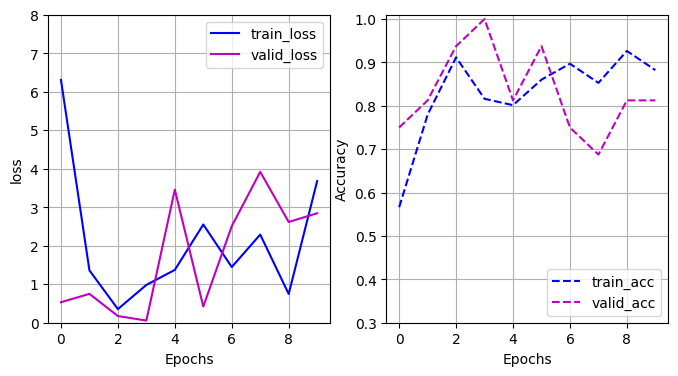

In [21]:
# plot the loss curve
epoch_arr = range(len(results['train_acc']))
fig, axes = plt.subplots(1,2, figsize=(4*2, 4))
ax = axes[0]
ax.plot(epoch_arr, results['train_loss'], 'b-', label='train_loss')
ax.plot(epoch_arr, results['valid_loss'], 'm-',label='valid_loss')
ax.grid()
ax.set_ylim(0., 8)
ax.set_yticks(np.arange(0.,8+1, 1))
ax.set_ylabel("loss")
ax.set_xlabel("Epochs")
ax.legend(loc='upper right')
ax= axes[1]
ax.plot(epoch_arr, results['train_acc'], 'b--', label='train_acc')
ax.plot(epoch_arr, results['valid_acc'], 'm--', label='valid_acc')
ax.legend(loc='lower right')
ax.set_ylim(0.3,1+0.01)
ax.set_ylabel("Accuracy")
ax.set_yticks(np.arange(0.3,1+0.01,0.1))
ax.grid(True)
ax.set_xlabel("Epochs")


Making predictions on test set to see performance.

In [22]:
# metric
test_loss, test_acc = valid_step(model=model,
                                  dataloader=test_dl,
                                  loss_fn=loss_fn,
                                  device=device)
print(f"test_loss, test_acc : {test_loss}, {test_acc}")

test_loss, test_acc : 12.974982738494873, 0.5178571428571428


In [23]:
test_label_list = []
truth_list = []
with torch.inference_mode():
      # Loop over the dataloader
      for batch, (X, y) in enumerate(test_dl):
          X = X.to(device)
          truth_list += y.cpu()
          # forward
          test_pred = model(X)
          # accuracy metric
          test_pred_labels = test_pred.argmax(dim=1)
          test_label_list += test_pred_labels.cpu()

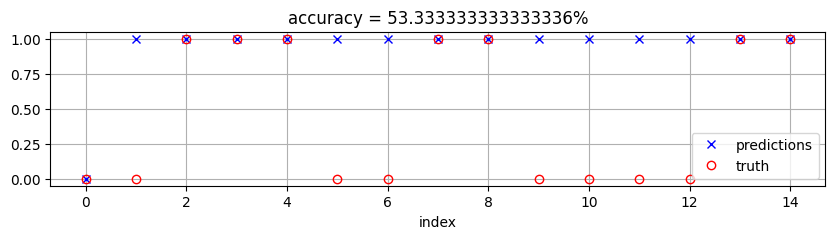

In [24]:
fig = plt.figure(figsize=(10, 2))
ax = plt.axes()
ax.plot(test_label_list, 'bx', label="predictions")
ax.plot(truth_list, 'ro', fillstyle="none", label="truth")
ax.set_xlabel("index")
ax.legend()
ax.grid()

accuracy = np.sum(np.array(test_label_list) == np.array(truth_list))/len(test_dataset)
ax.set_title(f"accuracy = {accuracy*100}%");

Performance is good (accuracy ~90-100%) for training and validation set, but a bit poorer for testing set.

Hope the above give you some insights on transfer learning. 😀